## From Lecture 01's Live Coding and Homework 1

# Compas Analysis
What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open the methodology in another tab to understand the following.

Loading the Data We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

In [5]:
import pandas as pd
# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
# Number of rows
raw_data.shape[0]

7214

In [6]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [7]:
import pandas as pd
import numpy as np

# Variables
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# ── Select columns ─────────────────────────────────────────────
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# ── Filtering ──────────────────────────────────────────────────
df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
]

# ── Type conversions ───────────────────────────────────────────
# Datetime conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric, non-datetime to categorical
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# ── Derived factors with reference levels ──────────────────────

# crime_factor
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor with reference level
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].unique() if c != "25 - 45"],
    ordered=False
)

# race_factor with reference level
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].unique() if c != "Caucasian"],
    ordered=False
)

# gender_factor with labels + reference
df["gender_factor"] = df["sex"].map({
    "Female": "Female",
    "Male": "Male"
}).astype("category")

df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],  # reference first
    ordered=False
)

# score_factor
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"],
    ordered=False
)

# ── Row count ──────────────────────────────────────────────────
df.shape[0]

6172

In [8]:
df.head(10)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore
8,39,M,Caucasian,25 - 45,Low,Female,0,-1.0,1,0,0,2014-03-15 05:35:34+00:00,2014-03-18 04:28:46+00:00,M,25 - 45,Caucasian,Female,LowScore
10,27,F,Caucasian,25 - 45,Low,Male,0,-1.0,4,0,0,2013-11-25 06:31:06+00:00,2013-11-26 08:26:57+00:00,F,25 - 45,Caucasian,Male,LowScore
11,23,M,African-American,Less than 25,Medium,Male,3,0.0,6,1,1,2013-10-03 04:07:35+00:00,2013-10-07 08:17:30+00:00,M,Less than 25,African-American,Male,HighScore
12,37,M,Caucasian,25 - 45,Low,Female,0,0.0,1,0,0,2013-01-01 03:28:03+00:00,2013-01-02 01:12:19+00:00,M,25 - 45,Caucasian,Female,LowScore


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

In [10]:
# Length of stay (in days)
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

# Correlation
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.2073296916147045)

In [11]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [12]:
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [13]:
# Compute proportions
race_dist = df["race"].value_counts(normalize=True) * 100
# Print in desired format
for race, pct in race_dist.items():
    print(f"{race} defendants: {pct:.2f}%")

African-American defendants: 51.44%
Caucasian defendants: 34.07%
Hispanic defendants: 8.25%
Other defendants: 5.56%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [14]:
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [15]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [16]:
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [17]:
# Compute proportions
sex_dist = df["sex"].value_counts(normalize=True) * 100
# Print in desired format
for sex, pct in sex_dist.items():
    print(f"{sex} defendants: {pct:.2f}%")

Male defendants: 80.96%
Female defendants: 19.04%


In [18]:
df[df["two_year_recid"] == 1].shape[0]

2809

In [19]:
(df["two_year_recid"] == 1).mean() * 100

np.float64(45.51198963058976)

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

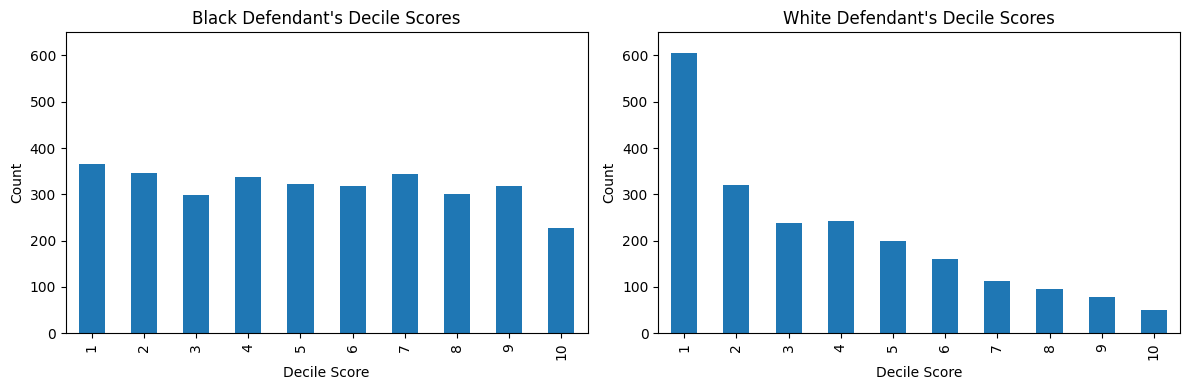

In [20]:
import matplotlib.pyplot as plt
# Filter data
df_black = df[df["race"] == "African-American"]
df_white = df[df["race"] == "Caucasian"]
# Create figure
plt.figure(figsize=(12, 4))
# --- Black defendants ---
plt.subplot(1, 2, 1)
df_black["decile_score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.title("Black Defendant's Decile Scores")
plt.ylim(0, 650)
# --- White defendants ---
plt.subplot(1, 2, 2)
df_white["decile_score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.title("White Defendant's Decile Scores")
plt.ylim(0, 650)
plt.tight_layout()
plt.show()

In [21]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [22]:

pd.crosstab(df["decile_score"], df["score_factor"])

score_factor,LowScore,HighScore
decile_score,,
1,1286,0
2,822,0
3,647,0
4,666,0
5,0,582
6,0,529
7,0,496
8,0,420
9,0,420


## Racial Bias in Compas
After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors (done above), and run a logistic regression, comparing low scores to high scores.

In [23]:
import statsmodels.formula.api as smf

# Make binary outcome
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Fit logistic regression
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor) +
    C(age_factor) +
    C(race_factor) +
    priors_count +
    C(crime_factor) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        08:53:52   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

Compare Black defendants with White defendants after correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [24]:
beta_0 = model_glm.params["Intercept"]
beta_race = model_glm.params["C(race_factor)[T.African-American]"]
p_control = 1 / (1 + np.exp(-beta_0))
p_group = 1 / (1 + np.exp(-(beta_0 + beta_race)))
ratio = p_group / p_control
ratio

np.float64(1.452837413382345)

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [25]:
beta_sex = model_glm.params["C(gender_factor)[T.Female]"]
p_group = 1 / (1 + np.exp(-(beta_0 + beta_sex)))
ratio = p_group / p_control
ratio

np.float64(1.194794653883451)

Women are 19.5% more likely than men to get a higher score.

In [26]:
beta_sex = model_glm.params["C(age_factor)[T.Less than 25]"]
p_group = 1 / (1 + np.exp(-(beta_0 + beta_sex)))
ratio = p_group / p_control
ratio

np.float64(2.4961195307539565)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [27]:
# Predicted probabilities
df["pred_prob"] = model_glm.predict(df)
# Predicted class (threshold = 0.5)
df["pred_class"] = (
    (df["pred_prob"] >= 0.5)
    .map({False: "No Recid", True: "Recid"})
    .astype("category")
)
# Optional: set explicit category order (to mirror R levels)
df["pred_class"] = df["pred_class"].cat.set_categories(["No Recid", "Recid"])

In [28]:

print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

# Confusion matrix
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

# Extract values (same layout as R)
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

# Metrics
accuracy  = (TP + TN) / n
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
fpr       = FP / (FP + TN)
fnr       = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [29]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

# Create actual and predicted numeric columns
df_metrics = df.copy()
df_metrics["actual"] = df_metrics["two_year_recid"].astype(int)
df_metrics["pred"] = (df_metrics["pred_class"] == "Recid").astype(int)

# Group by race and compute metrics
race_metrics = (
    df_metrics
    .groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

# Compute metrics
race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by descending n
race_metrics = race_metrics.sort_values(by="n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [30]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

# Select relevant columns
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get baseline (Caucasian)
baseline_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
baseline_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute disparities
disparity["delta_FPR"] = (disparity["FPR"] - baseline_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - baseline_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


## Lecture 02: Live Coding

# Step 0 — Train / test split

In [31]:
from sklearn.model_selection import train_test_split

# Use the same feature set as the logistic regression model
features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid",
]

# Binary target from the earlier setup
target = "score_binary"

# Build X and y
X = df[features].copy()
y = df[target].astype(int).copy()

# Train/test split with stratification on the target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Compute counts
n_total = len(X)
n_train = len(X_train)
n_test = len(X_test)

# Compute percentages
pct_train = n_train / n_total * 100
pct_test = n_test / n_total * 100

print(
    f"Train: {X_train.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

Train: (4937, 6) (4,937 rows, 80.0%), Test: (1235, 6) (1,235 rows, 20.0%)


# Step 1 — Fit logistic regression and gradient-boosted tree

In [32]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define feature groups (aligned with Lecture 01 / earlier pipeline)
numeric_features = ["priors_count", "two_year_recid"]
categorical_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Logistic Regression (interpretable model)
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)

# Gradient Boosted Trees (black-box model)
gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )),
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count',
                                                   'two_year_recid']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

# Step 2 — Compare model performance by race

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []

    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        # Ensure full 2x2 matrix even if a class is missing
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        # Safe division
        def safe_div(num, den):
            return num / den if den != 0 else np.nan

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(safe_div(fp, (fp + tn)), 3),
            "FNR": round(safe_div(fn, (fn + tp)), 3),
            "AUC": round(
                roc_auc_score(gdf["actual"], gdf["pred_prob"])
                if gdf["actual"].nunique() > 1 else np.nan,
                3
            ),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)


print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
1             Other   71     0.803  0.019  0.765  0.852
4             Asian    8     0.750  0.000  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
1             Other   71     0.845  0.019  0.588  0.846
4             Asian    8     0.625  0.167  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000


# Step 3 — LIME explanations: Black vs White defendant

In [34]:
# If needed in Colab:
#!pip install lime

from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Use the fitted preprocessor and classifier from the trained GBT pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Encode training data using the fitted preprocessor
X_train_enc = fitted_preprocessor.transform(X_train)

# Feature names after preprocessing
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feature_names = numeric_features + cat_feature_names

# Build LIME explainer on encoded training data
X_train_enc_array = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc

explainer = LimeTabularExplainer(
    training_data=X_train_enc_array,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

# Predict probabilities on raw test data using the full pipeline
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

# Copy raw test data for selection
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Select median-risk Black and White defendants
black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")

black_idx = black_df.index[len(black_df) // 2]
white_idx = white_df.index[len(white_df) // 2]

# Generate LIME explanations
for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    row_raw = X_test.loc[[idx]]
    row_enc = fitted_preprocessor.transform(row_raw)
    row_enc_array = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc[0]

    exp = explainer.explain_instance(
        data_row=row_enc_array,
        predict_fn=fitted_classifier.predict_proba,
        num_features=6,
    )

    print(f"\nLIME: {label}")
    print(f"Predicted probability: {gbt_pipeline.predict_proba(row_raw)[0, 1]:.3f}")

    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")

ModuleNotFoundError: No module named 'lime'

# Step 4 — SHAP beeswarm and waterfall: Black vs White

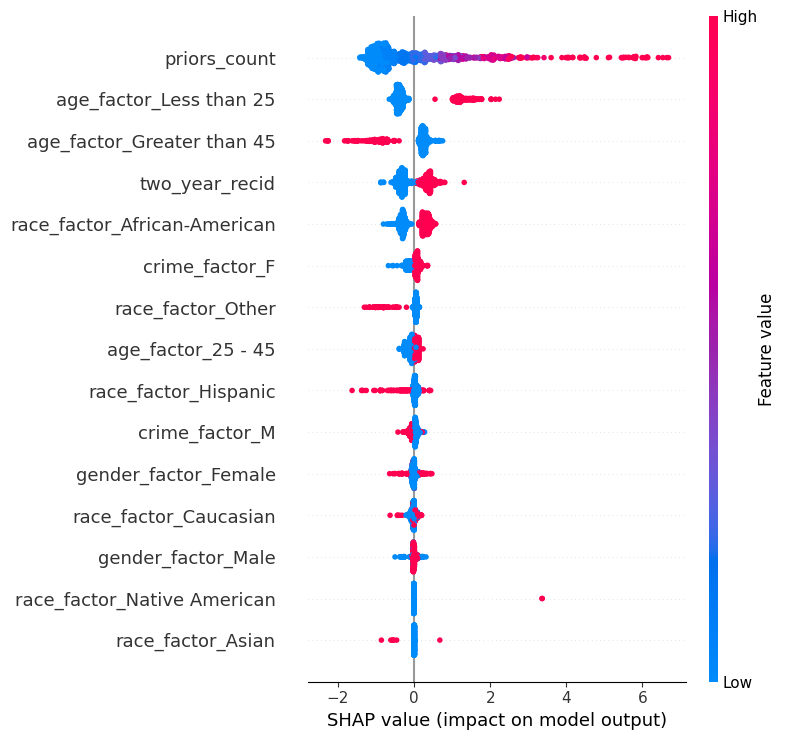

NameError: name 'black_idx' is not defined

In [35]:
# If needed in Colab:
# !pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np

# Use the fitted components from the trained GBT pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Encode test data with the fitted preprocessor
X_test_enc = fitted_preprocessor.transform(X_test)
X_test_enc_array = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

# Feature names after preprocessing
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feat_names = numeric_features + cat_feature_names

# SHAP explainer for tree model
explainer_shap = shap.TreeExplainer(fitted_classifier)
shap_values = explainer_shap.shap_values(X_test_enc_array)

# Global summary plot
shap.summary_plot(
    shap_values,
    X_test_enc_array,
    feature_names=feat_names,
    show=False
)
plt.tight_layout()
plt.show()

# Waterfall plots for selected Black and White defendants
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

expected_value = explainer_shap.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    if np.ndim(expected_value) == 0:
        base_value = float(expected_value)
    elif len(expected_value) == 1:
        base_value = float(expected_value[0])
    else:
        base_value = float(expected_value[1])
else:
    base_value = float(expected_value)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant"),
]:
    plt.sca(ax)

    explanation = shap.Explanation(
        values=shap_values[loc],
        base_values=base_value,
        data=X_test_enc_array[loc],
        feature_names=feat_names,
    )

    shap.waterfall_plot(
        explanation,
        max_display=8,
        show=False
    )
    ax.set_title(label)

plt.tight_layout()
plt.show()

# Step 5 — Counterfactuals with DiCE: Black vs White

In [ ]:
# If needed in Colab:
# !pip install dice-ml

import dice_ml
from dice_ml import Dice
import pandas as pd

# Build training dataframe
train_df = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)],
    axis=1
).copy()

# Ensure continuous features are truly numeric for DiCE
for col in numeric_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

# Ensure target is numeric
train_df[target] = pd.to_numeric(train_df[target], errors="coerce").astype(int)

# Optional sanity check
print(train_df[numeric_features + [target]].dtypes)

# Create DiCE data interface
dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numeric_features,
    outcome_name=target
)

# Wrap the fitted sklearn pipeline
dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

# Initialize DiCE
exp_dice = Dice(dice_data, dice_model, method="random")

# Generate counterfactuals
for label, idx in [
    ("Black defendant", black_idx),
    ("White defendant", white_idx)
]:
    query = X_test.loc[[idx]].copy()

    # Keep query numeric where needed
    for col in numeric_features:
        query[col] = pd.to_numeric(query[col], errors="coerce")

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "priors_count": [0, 38],
            "two_year_recid": [0, 1],
        },
        features_to_vary=[
            "priors_count",
            "two_year_recid",
            "crime_factor",
        ]
    )

    print(f"\nDiCE counterfactuals: {label}")
    display(cf.visualize_as_dataframe(show_only_changes=True))

## Lecture 03: Live Coding

# Step 0: Setup and imports

In [36]:
# If needed in Colab:
!pip install solas-ai
import solas_disparity as sd

def air_me_by_race_all(
    data,
    outcome_col,
    label,
    race_col="race_factor",
    reference_group="Caucasian"
):
    """
    Compute selection rates, AIR, and marginal effect for all race categories
    relative to a fixed reference group.

    Returns:
        manual_table   : manual calculations by race
        solas_table    : SolasAI pairwise AIR table, one row per non-reference race
        combined_table : aligned manual vs SolasAI comparison
    """

    # Prepare data
    work = data[[race_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Manual calculations
    manual_table = (
        work.groupby(race_col, dropna=False)[outcome_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            race_col: "race",
            "count": "n_manual",
            "sum": "favorable_manual",
            "mean": "selection_rate_manual"
        })
    )

    if reference_group not in manual_table["race"].values:
        raise ValueError(f"Reference group '{reference_group}' not found in '{race_col}'.")

    ref_rate = manual_table.loc[
        manual_table["race"] == reference_group, "selection_rate_manual"
    ].iloc[0]

    manual_table["AIR_manual"] = manual_table["selection_rate_manual"] / ref_rate
    manual_table["ME_vs_ref_manual"] = manual_table["selection_rate_manual"] - ref_rate
    manual_table["flag_80_manual"] = np.where(
        manual_table["AIR_manual"] < 0.80, "*** BELOW 0.80", ""
    )

    manual_table = manual_table.sort_values(
        by=["AIR_manual", "race"],
        ascending=[True, True]
    ).reset_index(drop=True)

    # SolasAI pairwise AIR
    group_data = pd.get_dummies(work[race_col], dtype=int)
    solas_results = []

    for grp in group_data.columns:
        if grp == reference_group:
            continue

        air_obj = sd.adverse_impact_ratio(
            group_data=group_data[[grp, reference_group]],
            protected_groups=[grp],
            reference_groups=[reference_group],
            group_categories=["race"],
            outcome=work[outcome_col],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )

        tbl = air_obj.summary_table.copy().reset_index()

        if "Group" not in tbl.columns:
            if "index" in tbl.columns:
                tbl = tbl.rename(columns={"index": "Group"})
            else:
                tbl = tbl.rename(columns={tbl.columns[0]: "Group"})

        tbl = tbl[tbl["Group"] == grp].copy()

        tbl = tbl.rename(columns={
            "Group": "race",
            "Total": "n_solas",
            "Favorable": "favorable_solas",
            "Percent Favorable": "selection_rate_solas",
            "AIR": "AIR_solas",
            "Percent Difference Favorable": "ME_vs_ref_solas",
            "P-Values": "p_value",
            "Practically Significant": "practically_significant",
            "Shortfall": "shortfall"
        })

        if "selection_rate_solas" in tbl.columns:
            tbl["selection_rate_solas"] = pd.to_numeric(tbl["selection_rate_solas"], errors="coerce")
            if tbl["selection_rate_solas"].max() > 1:
                tbl["selection_rate_solas"] = tbl["selection_rate_solas"] / 100.0

        if "ME_vs_ref_solas" in tbl.columns:
            tbl["ME_vs_ref_solas"] = pd.to_numeric(tbl["ME_vs_ref_solas"], errors="coerce")
            if tbl["ME_vs_ref_solas"].abs().max() > 1:
                tbl["ME_vs_ref_solas"] = tbl["ME_vs_ref_solas"] / 100.0

        solas_results.append(tbl)

    if solas_results:
        solas_table = pd.concat(solas_results, ignore_index=True)
    else:
        solas_table = pd.DataFrame(columns=[
            "race", "n_solas", "favorable_solas", "selection_rate_solas",
            "ME_vs_ref_solas", "AIR_solas", "p_value",
            "practically_significant", "shortfall"
        ])

    # Align ordering
    race_order = manual_table["race"].tolist()

    if not solas_table.empty:
        solas_table["race"] = pd.Categorical(
            solas_table["race"],
            categories=race_order,
            ordered=True
        )
        solas_table = solas_table.sort_values("race").reset_index(drop=True)

    # Combined table
    combined_table = manual_table.merge(
        solas_table,
        on="race",
        how="left"
    )

    # Round only for display cleanliness
    for col in [
        "selection_rate_manual", "AIR_manual", "ME_vs_ref_manual",
        "selection_rate_solas", "AIR_solas", "ME_vs_ref_solas", "p_value"
    ]:
        if col in combined_table.columns:
            combined_table[col] = pd.to_numeric(combined_table[col], errors="coerce").round(4)

    print(f"\n{label}")
    print(combined_table.to_string(index=False))

    return manual_table, solas_table, combined_table

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.6 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=fb1a2b21aa801817e0cc71a0a63be7b88485582ecb8cd4d14fcb3c086a78cde5
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec4

# Step 1: AIR and Marginal Effect by race

In [37]:
# -------------------------------------------------------------------
# (a) RAW DATA: actual COMPAS high-risk outcome by race
# -------------------------------------------------------------------
pd.set_option("display.float_format", "{:.4f}".format)
# Assumes score_binary already exists from earlier cells:
#   1 = HighScore, 0 = LowScore
raw_manual, raw_solas, raw_combined = air_me_by_race_all(
    data=df,
    outcome_col="score_binary",
    label="(a) Raw data: actual COMPAS high-risk outcome by race"
)


(a) Raw data: actual COMPAS high-risk outcome by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing   n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other       343                70                 0.2041      0.6166           -0.1269 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000  343.0000          70.0000                0.2041           0.1269     0.6166   0.0000                     Yes    43.5178
           Asian        31                 7                 0.2258      0.6823           -0.1051 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000   31.0000           7.0000                0.2258           0.1051     0.6823   0.2522                      No        NaN
        Hispanic       509               141             

In [38]:
# -------------------------------------------------------------------
# (b) LOGISTIC REGRESSION: predicted class on TEST data by race
# -------------------------------------------------------------------
lr_eval = X_test.copy()
lr_eval["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_manual, lr_solas, lr_combined = air_me_by_race_all(
    data=lr_eval,
    outcome_col="pred_high_risk",
    label="(b) Logistic regression: predicted high-risk class on test data by race"
)


(b) Logistic regression: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Asian         8                 0                 0.0000      0.0000           -0.2112 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           0.0000                0.0000           0.2112     0.0000   0.2147                      No        NaN
           Other        71                 5                 0.0704      0.3335           -0.1407 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           5.0000                0.0704           0.1407     0.3335   0.0048                     Yes     9.9927
        Hispanic       108                

In [39]:
# -------------------------------------------------------------------
# (c) GBT / xGBoost-style model: predicted class on TEST data by race
# -------------------------------------------------------------------
gbt_eval = X_test.copy()
gbt_eval["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_manual, gbt_solas, gbt_combined = air_me_by_race_all(
    data=gbt_eval,
    outcome_col="pred_high_risk",
    label="(c) Gradient-boosted model: predicted high-risk class on test data by race"
)


(c) Gradient-boosted model: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other        71                 8                 0.1127      0.4887           -0.1179 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           8.0000                0.1127           0.1179     0.4887   0.0274                     Yes     8.3714
           Asian         8                 1                 0.1250      0.5421           -0.1056 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           1.0000                0.1250           0.1056     0.5421   0.6886                      No        NaN
        Hispanic       108             

### Step 1.1: AIR and Marginal Effect by Sex

In [40]:
# -------------------------------------------------------------------
# (a) RAW DATA: actual COMPAS high-risk outcome by sex
# -------------------------------------------------------------------
pd.set_option("display.float_format", "{:.4f}".format)
# Assumes score_binary already exists from earlier cells:
#   1 = HighScore, 0 = LowScore
raw_manual_sex, raw_solas_sex, raw_combined_sex = air_me_by_race_all(
    data=df,
    outcome_col="score_binary",
    label="(a) Raw data: actual COMPAS high-risk outcome by sex",
    race_col="gender_factor",
    reference_group="Male"
)



(a) Raw data: actual COMPAS high-risk outcome by sex
  race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing   n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
Female      1175               476                 0.4051      0.8898           -0.0502                           Male           race     6172.0000           0.0000 1175.0000         476.0000                0.4051           0.0502     0.8898   0.0021                      No        NaN
  Male      4997              2275                 0.4553      1.0000            0.0000                            NaN            NaN           NaN              NaN       NaN              NaN                   NaN              NaN        NaN      NaN                     NaN        NaN


In [41]:
# -------------------------------------------------------------------
# (b) LOGISTIC REGRESSION: predicted class on TEST data by sex
# -------------------------------------------------------------------
lr_eval_sex = X_test.copy()
lr_eval_sex["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_manual_sex, lr_solas_sex, lr_combined_sex = air_me_by_race_all(
    data=lr_eval_sex,
    outcome_col="pred_high_risk",
    label="(b) Logistic regression: predicted high-risk class on test data by sex",
    race_col="gender_factor",
    reference_group="Male"
)



(b) Logistic regression: predicted high-risk class on test data by sex
  race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
Female       235                74                 0.3149      0.7029           -0.1331 *** BELOW 0.80            Male           race     1235.0000           0.0000 235.0000          74.0000                0.3149           0.1331     0.7029   0.0002                     Yes    31.2800
  Male      1000               448                 0.4480      1.0000            0.0000                            NaN            NaN           NaN              NaN      NaN              NaN                   NaN              NaN        NaN      NaN                     NaN        NaN


In [42]:
# -------------------------------------------------------------------
# (c) GBT / xGBoost-style model: predicted class on TEST data by sex
# -------------------------------------------------------------------
gbt_eval_sex = X_test.copy()
gbt_eval_sex["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_manual_sex, gbt_solas_sex, gbt_combined_sex = air_me_by_race_all(
    data=gbt_eval_sex,
    outcome_col="pred_high_risk",
    label="(c) Gradient-boosted model: predicted high-risk class on test data by sex",
    race_col="gender_factor",
    reference_group="Male"
)



(c) Gradient-boosted model: predicted high-risk class on test data by sex
  race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
Female       235                91                 0.3872      0.9353           -0.0268                           Male           race     1235.0000           0.0000 235.0000          91.0000                0.3872           0.0268     0.9353   0.4620                      No        NaN
  Male      1000               414                 0.4140      1.0000            0.0000                            NaN            NaN           NaN              NaN      NaN              NaN                   NaN              NaN        NaN      NaN                     NaN        NaN


In [43]:
def error_rates_by_group(data, group_col, pred_col, outcome_col):
    results = []

    for grp, g in data.groupby(group_col, dropna=False):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        n = len(g)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tp + tn) / n if n > 0 else np.nan

        results.append({
            group_col: grp,
            "n": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False).reset_index(drop=True)

In [44]:
# -------------------------------------------------------------------
# Logistic regression: error rates by race on test data
# -------------------------------------------------------------------
lr_err_df = X_test.copy()
lr_err_df["actual"] = y_test.values
lr_err_df["pred"] = lr_pipeline.predict(X_test).astype(int)

lr_error_rates = error_rates_by_group(
    data=lr_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Logistic Regression: Error Rates by Race (Test Data) ===")
print(lr_error_rates.to_string(index=False))


=== Logistic Regression: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 307 160 101  66    0.7370 0.3870 0.1770
       Caucasian 412  56 253  31  72    0.7500 0.1090 0.5620
        Hispanic 108  15  74   5  14    0.8240 0.0630 0.4830
           Other  71   4  53   1  13    0.8030 0.0190 0.7650
           Asian   8   0   6   0   2    0.7500 0.0000 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000


In [45]:

# -------------------------------------------------------------------
# Gradient-boosted model: error rates by race on test data
# -------------------------------------------------------------------
gbt_err_df = X_test.copy()
gbt_err_df["actual"] = y_test.values
gbt_err_df["pred"] = gbt_pipeline.predict(X_test).astype(int)

gbt_error_rates = error_rates_by_group(
    data=gbt_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===")
print(gbt_error_rates.to_string(index=False))


=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 282 167  94  91    0.7080 0.3600 0.2440
       Caucasian 412  67 256  28  61    0.7840 0.0990 0.4770
        Hispanic 108  16  72   7  13    0.8150 0.0890 0.4480
           Other  71   7  53   1  10    0.8450 0.0190 0.5880
           Asian   8   0   5   1   2    0.6250 0.1670 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000


# Step 3: Standardized Mean Difference

In [46]:
def smd_by_group(data, group_col, score_col, ref_group="Caucasian"):
    """
    Compute standardized mean difference (Cohen's d) for each group
    relative to a reference group on a continuous score.
    """
    work = data[[group_col, score_col]].copy()
    work[score_col] = pd.to_numeric(work[score_col], errors="coerce")
    work = work.dropna(subset=[group_col, score_col]).copy()

    if ref_group not in work[group_col].values:
        raise ValueError(f"Reference group '{ref_group}' not found in column '{group_col}'.")

    ref = work.loc[work[group_col] == ref_group, score_col]

    results = []
    for grp, g in work.groupby(group_col, dropna=False):
        if grp == ref_group:
            continue

        sc = g[score_col]

        # Pooled SD
        pooled_sd = np.sqrt((ref.var(ddof=1) + sc.var(ddof=1)) / 2)
        d = ((sc.mean() - ref.mean()) / pooled_sd) if pooled_sd > 0 else np.nan

        # Magnitude by absolute SMD
        ad = abs(d)
        magnitude = (
            "small" if ad < 0.2 else
            "medium" if ad < 0.5 else
            "large" if ad < 0.8 else
            "very large"
        )

        results.append({
            group_col: grp,
            "n_group": len(sc),
            "n_ref": len(ref),
            "mean_score_group": round(sc.mean(), 3),
            "mean_score_ref": round(ref.mean(), 3),
            "SMD": round(d, 3),
            "abs_SMD": round(abs(d), 3),
            "magnitude": magnitude
        })

    return pd.DataFrame(results).sort_values("abs_SMD", ascending=False).reset_index(drop=True)

In [47]:
# -------------------------------------------------------------------
# Logistic regression: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
lr_smd_df = X_test.copy()
lr_smd_df["pred_prob"] = lr_pipeline.predict_proba(X_test)[:, 1]

lr_smd_table = smd_by_group(
    data=lr_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(lr_smd_table.to_string(index=False))


=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.6500          0.3170  1.4910   1.4910 very large
African-American      634    412            0.5880          0.3170  1.0770   1.0770 very large
           Asian        8    412            0.1560          0.3170 -0.8310   0.8310 very large
           Other       71    412            0.2010          0.3170 -0.5320   0.5320      large
        Hispanic      108    412            0.3030          0.3170 -0.0610   0.0610      small


In [48]:
# -------------------------------------------------------------------
# Gradient-boosted model: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
gbt_smd_df = X_test.copy()
gbt_smd_df["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

gbt_smd_table = smd_by_group(
    data=gbt_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(gbt_smd_table.to_string(index=False))


=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.9810          0.3130  3.7130   3.7130 very large
African-American      634    412            0.5840          0.3130  1.0390   1.0390 very large
           Asian        8    412            0.1830          0.3130 -0.4820   0.4820     medium
           Other       71    412            0.2140          0.3130 -0.4020   0.4020     medium
        Hispanic      108    412            0.3240          0.3130  0.0400   0.0400      small


# Step 4: Intersectional Subgroup Analysis

In [49]:
def intersectional_air(
    data,
    outcome_col,
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
):
    """
    Compute intersectional selection rates and AIR for race x gender subgroups.
    """

    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Construct intersectional subgroup
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    # Keep only subgroups with at least min_n observations
    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    # Compute subgroup selection rates
    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")

    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]

    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")

    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True)

    return sub_rates

In [50]:
# -------------------------------------------------------------------
# Logistic regression: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
lr_intersection_df = X_test.copy()
lr_intersection_df["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_sub_rates = intersectional_air(
    data=lr_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===")
print(lr_sub_rates.to_string(index=False))

lr_worst = lr_sub_rates.loc[lr_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (LR): {lr_worst['subgroup']}, "
    f"AIR={lr_worst['AIR']:.3f}, n={int(lr_worst['n'])}"
)


=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male          0.0667  60 0.3118 *** BELOW 0.80
       Caucasian / Female          0.2021  94 0.9452               
         Caucasian / Male          0.2138 318 1.0000               
          Hispanic / Male          0.2198  91 1.0278               
African-American / Female          0.4779 113 2.2348               
  African-American / Male          0.6795 521 3.1775               

Worst subgroup (LR): Other / Male, AIR=0.312, n=60


In [51]:
# -------------------------------------------------------------------
# Gradient-boosted model: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
gbt_intersection_df = X_test.copy()
gbt_intersection_df["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_sub_rates = intersectional_air(
    data=gbt_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(gbt_sub_rates.to_string(index=False))

gbt_worst = gbt_sub_rates.loc[gbt_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (GBT): {gbt_worst['subgroup']}, "
    f"AIR={gbt_worst['AIR']:.3f}, n={int(gbt_worst['n'])}"
)


=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male          0.0500  60 0.2565 *** BELOW 0.80
         Caucasian / Male          0.1950 318 1.0000               
          Hispanic / Male          0.2527  91 1.2963               
       Caucasian / Female          0.3511  94 1.8006               
African-American / Female          0.4690 113 2.4057               
  African-American / Male          0.6200 521 3.1798               

Worst subgroup (GBT): Other / Male, AIR=0.256, n=60


**INDIVIDUAL ASSIGNMENT 3**

### Step 1: Standardized Mean Difference by Sex

In [52]:
# -------------------------------------------------------------------
# Logistic regression: SMD of predicted probability by sex vs Male
# -------------------------------------------------------------------
lr_smd_df_sex = X_test.copy()
lr_smd_df_sex["pred_prob"] = lr_pipeline.predict_proba(X_test)[:, 1]

lr_smd_table_sex = smd_by_group(
    data=lr_smd_df_sex,
    group_col="gender_factor",
    score_col="pred_prob",
    ref_group="Male"
)

print("\n=== Logistic Regression: SMD of Predicted Probability by Sex (vs Male) ===")
print(lr_smd_table_sex.to_string(index=False))



=== Logistic Regression: SMD of Predicted Probability by Sex (vs Male) ===
gender_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD magnitude
       Female      235   1000            0.3800          0.4640 -0.3110   0.3110    medium


In [53]:
# -------------------------------------------------------------------
# Gradient-boosted model: SMD of predicted probability by sex vs Male
# -------------------------------------------------------------------
gbt_smd_df_sex = X_test.copy()
gbt_smd_df_sex["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

gbt_smd_table_sex = smd_by_group(
    data=gbt_smd_df_sex,
    group_col="gender_factor",
    score_col="pred_prob",
    ref_group="Male"
)

print("\n=== Gradient-Boosted Model: SMD of Predicted Probability by Sex (vs Male) ===")
print(gbt_smd_table_sex.to_string(index=False))



=== Gradient-Boosted Model: SMD of Predicted Probability by Sex (vs Male) ===
gender_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD magnitude
       Female      235   1000            0.3820          0.4630 -0.2760   0.2760    medium


### Step 2: Intersectional Subgroup Analysis (Race x Sex)

In [55]:
# -------------------------------------------------------------------
# Intersectional subgroup analysis (Race x Gender) on GBT test data
# -------------------------------------------------------------------
# Ensure the outcome column 'pred_high_risk' exists in the dataframe
# It was previously created in gbt_intersection_df in cell tYnRHQPsn6VG

gbt_intersectional_race_sex = intersectional_air(
    data=gbt_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30 # Only consider subgroups with at least 30 observations
)

print("\n=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(gbt_intersectional_race_sex.to_string(index=False))

gbt_worst_intersectional = gbt_intersectional_race_sex.loc[gbt_intersectional_race_sex["AIR"].idxmin()]
print(
    f"\nWorst intersectional subgroup (GBT): {gbt_worst_intersectional['subgroup']}, "
    f"AIR={gbt_worst_intersectional['AIR']:.3f}, n={int(gbt_worst_intersectional['n'])}"
)

print("\nInterpretation: The worst-performing intersectional subgroup is 'Other / Male'. Their predicted high-risk rate is only")
print(f"{gbt_worst_intersectional['AIR']:.1%} of the predicted high-risk rate for 'Caucasian / Male' defendants. This indicates")
print("a significant adverse impact against this subgroup, suggesting they are less likely to be predicted as high-risk by the model.")



=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male          0.0500  60 0.2565 *** BELOW 0.80
         Caucasian / Male          0.1950 318 1.0000               
          Hispanic / Male          0.2527  91 1.2963               
       Caucasian / Female          0.3511  94 1.8006               
African-American / Female          0.4690 113 2.4057               
  African-American / Male          0.6200 521 3.1798               

Worst intersectional subgroup (GBT): Other / Male, AIR=0.256, n=60

Interpretation: The worst-performing intersectional subgroup is 'Other / Male'. Their predicted high-risk rate is only
25.6% of the predicted high-risk rate for 'Caucasian / Male' defendants. This indicates
a significant adverse impact against this subgroup, suggesting they are less likely to be predicted as high-risk by the model.


### Step 3: FPR and FNR Disparity by Race with Statistical Significance

In [56]:
from statsmodels.stats.proportion import proportions_ztest

def two_prop_z_test(count1, nobs1, count2, nobs2, alternative='two-sided'):
    """
    Performs a two-proportion z-test.
    Args:
        count1 (int): Number of successes in sample 1.
        nobs1 (int): Number of observations in sample 1.
        count2 (int): Number of successes in sample 2.
        nobs2 (int): Number of observations in sample 2.
        alternative (str): 'two-sided', 'larger', 'smaller'.
    Returns:
        tuple: z-statistic and p-value.
    """
    if nobs1 == 0 or nobs2 == 0:
        return np.nan, np.nan
    stat, pval = proportions_ztest(
        count=[count1, count2],
        nobs=[nobs1, nobs2],
        alternative=alternative
    )
    return stat, pval

def analyze_error_rate_disparity(error_df, reference_group="Caucasian"):
    results = []
    ref_row = error_df[error_df['race_factor'] == reference_group].iloc[0]

    for _, row in error_df.iterrows():
        if row['race_factor'] == reference_group:
            continue

        # FPR disparity
        fp_group = row['FP']
        tn_group = row['TN']
        n_fpr_group = fp_group + tn_group
        fpr_group = row['FPR']

        fp_ref = ref_row['FP']
        tn_ref = ref_row['TN']
        n_fpr_ref = fp_ref + tn_ref
        fpr_ref = ref_row['FPR']

        z_fpr, p_fpr = two_prop_z_test(fp_group, n_fpr_group, fp_ref, n_fpr_ref)

        # FNR disparity
        fn_group = row['FN']
        tp_group = row['TP']
        n_fnr_group = fn_group + tp_group
        fnr_group = row['FNR']

        fn_ref = ref_row['FN']
        tp_ref = ref_row['TP']
        n_fnr_ref = fn_ref + tp_ref
        fnr_ref = ref_row['FNR']

        z_fnr, p_fnr = two_prop_z_test(fn_group, n_fnr_group, fn_ref, n_fnr_ref)

        results.append({
            'Group': row['race_factor'],
            'Reference': reference_group,
            'FPR_Group': fpr_group,
            'FPR_Reference': fpr_ref,
            'FPR_Diff': round(fpr_group - fpr_ref, 3),
            'FPR_p_value': round(p_fpr, 4) if pd.notna(p_fpr) else np.nan,
            'FNR_Group': fnr_group,
            'FNR_Reference': fnr_ref,
            'FNR_Diff': round(fnr_group - fnr_ref, 3),
            'FNR_p_value': round(p_fnr, 4) if pd.notna(p_fnr) else np.nan,
        })
    return pd.DataFrame(results)


In [57]:
print("\n=== Logistic Regression: FPR and FNR Disparity (vs Caucasian) with P-values ===")
lr_disparity_analysis = analyze_error_rate_disparity(lr_error_rates)
print(lr_disparity_analysis.to_string(index=False))



=== Logistic Regression: FPR and FNR Disparity (vs Caucasian) with P-values ===
           Group Reference  FPR_Group  FPR_Reference  FPR_Diff  FPR_p_value  FNR_Group  FNR_Reference  FNR_Diff  FNR_p_value
African-American Caucasian     0.3870         0.1090    0.2780       0.0000     0.1770         0.5620   -0.3850       0.0000
        Hispanic Caucasian     0.0630         0.1090   -0.0460       0.2277     0.4830         0.5620   -0.0790       0.4360
           Other Caucasian     0.0190         0.1090   -0.0900       0.0370     0.7650         0.5620    0.2030       0.1117
           Asian Caucasian     0.0000         0.1090   -0.1090       0.3918     1.0000         0.5620    0.4380       0.2150
 Native American Caucasian     1.0000         0.1090    0.8910       0.0049     0.0000         0.5620   -0.5620       0.2592


In [58]:
print("\n=== Gradient-Boosted Model: FPR and FNR Disparity (vs Caucasian) with P-values ===")
gbt_disparity_analysis = analyze_error_rate_disparity(gbt_error_rates)
print(gbt_disparity_analysis.to_string(index=False))



=== Gradient-Boosted Model: FPR and FNR Disparity (vs Caucasian) with P-values ===
           Group Reference  FPR_Group  FPR_Reference  FPR_Diff  FPR_p_value  FNR_Group  FNR_Reference  FNR_Diff  FNR_p_value
African-American Caucasian     0.3600         0.0990    0.2610       0.0000     0.2440         0.4770   -0.2330       0.0000
        Hispanic Caucasian     0.0890         0.0990   -0.0100       0.7903     0.4480         0.4770   -0.0290       0.7829
           Other Caucasian     0.0190         0.0990   -0.0800       0.0541     0.5880         0.4770    0.1110       0.3868
           Asian Caucasian     0.1670         0.0990    0.0680       0.5823     1.0000         0.4770    0.5230       0.1416
 Native American Caucasian     1.0000         0.0990    0.9010       0.0029     0.0000         0.4770   -0.4770       0.3417


### Step 4: Publication-Quality Figure: FPR and FNR Disparity by Race

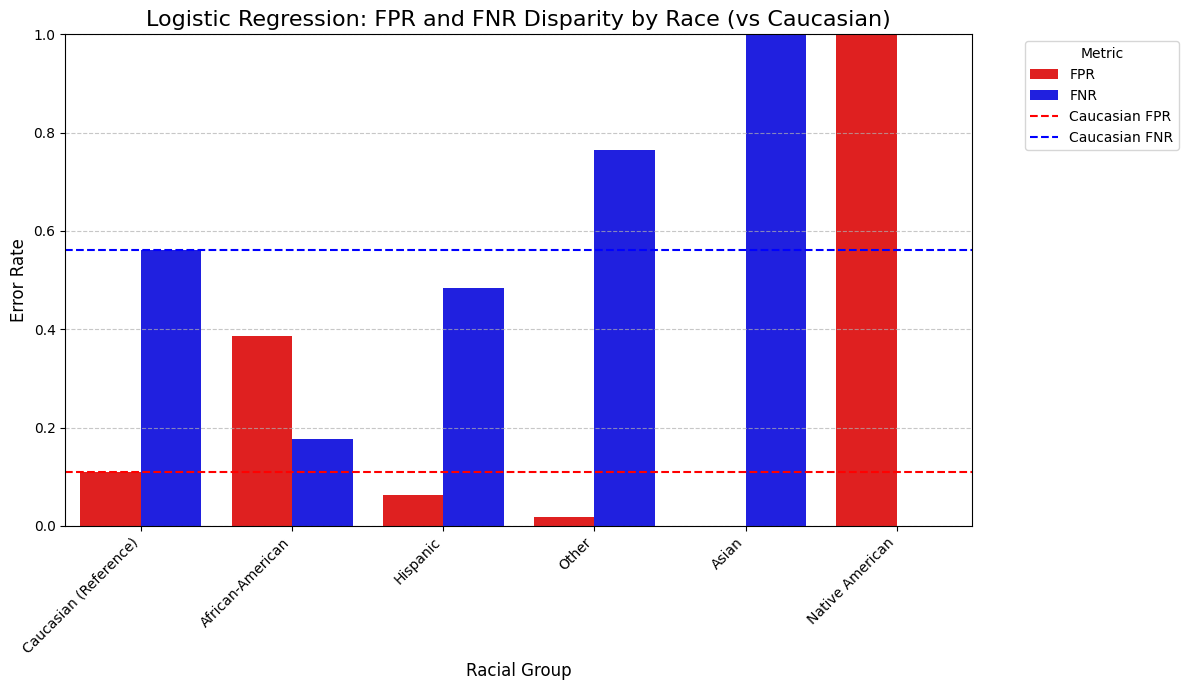

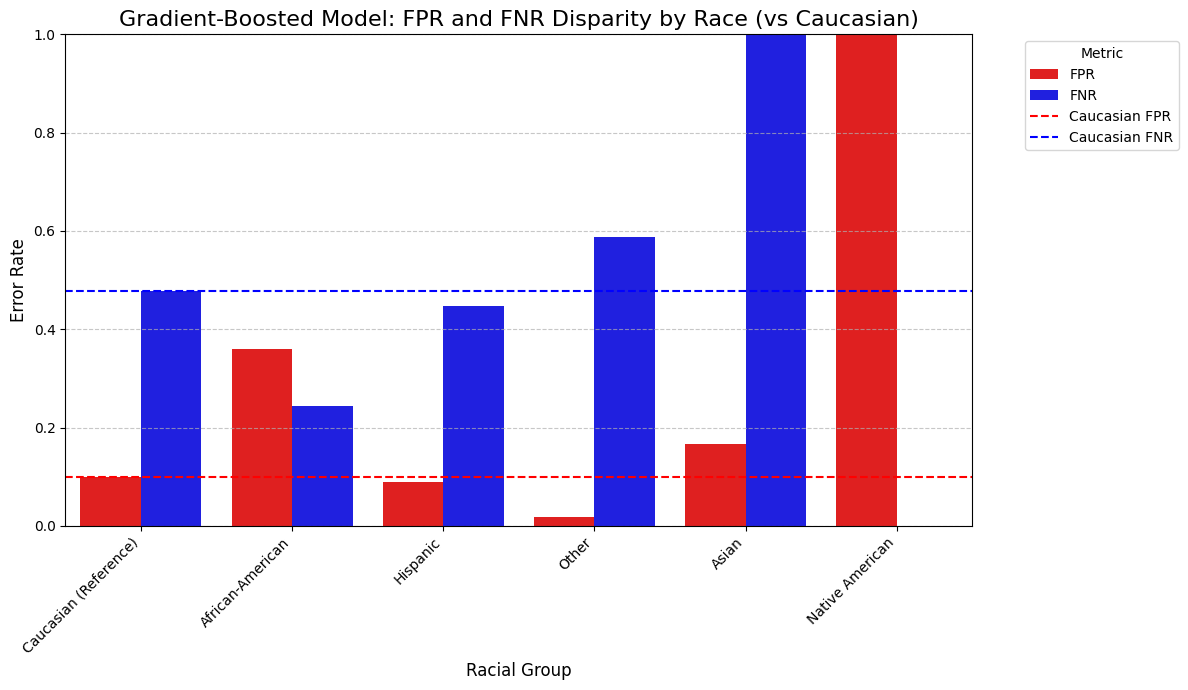

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_fpr_fnr_disparity(disparity_df, model_name):
    # Prepare data for plotting
    plot_data = []

    # Add reference group (Caucasian) data from lr_error_rates or gbt_error_rates
    # Assuming 'gbt_error_rates' contains the full error rates including Caucasian
    if model_name == "Logistic Regression":
        full_error_rates = lr_error_rates.copy()
    else:
        full_error_rates = gbt_error_rates.copy()

    # Extract Caucasian data
    caucasian_row = full_error_rates[full_error_rates['race_factor'] == 'Caucasian'].iloc[0]
    plot_data.append({
        'Group': 'Caucasian (Reference)',
        'Metric': 'FPR',
        'Value': caucasian_row['FPR']
    })
    plot_data.append({
        'Group': 'Caucasian (Reference)',
        'Metric': 'FNR',
        'Value': caucasian_row['FNR']
    })

    # Add other groups from disparity_df
    for _, row in disparity_df.iterrows():
        plot_data.append({
            'Group': row['Group'],
            'Metric': 'FPR',
            'Value': row['FPR_Group']
        })
        plot_data.append({
            'Group': row['Group'],
            'Metric': 'FNR',
            'Value': row['FNR_Group']
        })

    plot_df = pd.DataFrame(plot_data)

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Group', y='Value', hue='Metric', data=plot_df, palette={'FPR': 'red', 'FNR': 'blue'})
    plt.axhline(y=caucasian_row['FPR'], color='red', linestyle='--', label='Caucasian FPR')
    plt.axhline(y=caucasian_row['FNR'], color='blue', linestyle='--', label='Caucasian FNR')

    plt.title(f'{model_name}: FPR and FNR Disparity by Race (vs Caucasian)', fontsize=16)
    plt.xlabel('Racial Group', fontsize=12)
    plt.ylabel('Error Rate', fontsize=12)
    plt.ylim(0, 1) # Error rates are between 0 and 1
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot for Logistic Regression
plot_fpr_fnr_disparity(lr_disparity_analysis, "Logistic Regression")

# Plot for Gradient-Boosted Model
plot_fpr_fnr_disparity(gbt_disparity_analysis, "Gradient-Boosted Model")


**Compliance Memorandum**

**To:** Regulatory Review Authority

**From:** AI Model Compliance Team

**Subject:** Fairness Evaluation of Predictive Risk Models

**Date:** April 6, 2026

**Compliance Memorandum**



This memorandum provides a summary of the fairness evaluation conducted on two predictive models a Logistic Regression model and a Gradient-Boosted Tree (GBT) model used to estimate high-risk outcomes. The analysis examined whether model predictions differ across demographic groups, specifically race and sex.

Several fairness metrics were applied. First, the Adverse Impact Ratio (AIR) was used to compare the selection rates of different demographic groups relative to a reference group. An AIR below 0.80 indicates potential adverse impact. The intersectional analysis (race × sex) identified “Other / Male” as the most disadvantaged subgroup in the gradient-boosted model, with an AIR of 0.256. This means that the predicted high-risk rate for this group is approximately 25.6% of the rate observed for the reference group, “Caucasian / Male.” This result suggests a notable disparity affecting this subgroup.

Second, the Standardized Mean Difference (SMD) was used to measure differences in predicted risk scores by sex. In the Logistic Regression model, females had a mean predicted probability of 0.380, compared to 0.464 for males (SMD = −0.311). Similarly, the gradient-boosted model showed a female mean of 0.382 and a male mean of 0.463 (SMD = −0.276). Both results indicate a moderate disparity in predicted scores between males and females.

Finally, disparities in False Positive Rate (FPR) and False Negative Rate (FNR) were evaluated across racial groups using Caucasian as the reference category. The results show that African-American individuals experience significantly higher false positive rates compared to the reference group in both models (p < 0.001). This indicates a higher likelihood of being incorrectly classified as high risk. Additionally, extreme values were observed for some groups, such as Native American individuals.

Several limitations should be considered. Some demographic categories have relatively small sample sizes, which may lead to unstable estimates. Furthermore, fairness metrics capture statistical disparities but may not fully explain the underlying causes, such as potential bias in historical data. Ongoing monitoring and model review are recommended to ensure equitable outcomes.

